# Historical Overview Analysis

**Paper 2: Cross-Code Comparative Analysis - Part 8**

This notebook analyzes the historical evolution of Kazakhstan's legal codes:

1. **Version Loading**: Load all 563 historical versions across 5 codes
2. **Article Count Evolution**: Track how codes grow/shrink over time
3. **Amendment Frequency**: Analyze when and how often codes are amended
4. **Timeline Visualization**: Visual history of legal code evolution
5. **Version Index**: Build consolidated index for downstream analysis

**Data Source**: `data/raw/by_history/` containing version snapshots from 1996-2025

| Code | Versions | Date Range | Years |
|------|----------|------------|-------|
| ГК (Civil) | 179 | 1996-07-15 → 2025-11-20 | 29 |
| КоАП (Admin) | 205 | 2014-07-05 → 2025-12-17 | 11 |
| УК (Criminal) | 109 | 2014-07-03 → 2025-09-16 | 11 |
| ТК (Labor) | 69 | 2015-11-23 → 2025-09-16 | 10 |
| НК (Tax) | 1 | 2025-07-18 | <1 |

## 1. Setup and Imports

In [260]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

# Data paths
HISTORY_PATH = Path("../data/raw/by_history")
OUTPUT_DIR = Path("../output/08")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")
print(f"History data path: {HISTORY_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Setup complete!
History data path: ../data/raw/by_history
Output directory: ../output/08


## 2. Code Metadata

In [261]:
# Define code metadata with folder mappings
CODES = {
    "criminal": {
        "folder": "K1400000226_rus_ugolov",
        "doc_id": "K1400000226",
        "name_ru": "Уголовный кодекс",
        "name_en": "Criminal Code",
        "short": "УК",
        "color": "#e74c3c"  # red
    },
    "administrative": {
        "folder": "K1400000235_rus_adm",
        "doc_id": "K1400000235",
        "name_ru": "Кодекс об административных правонарушениях",
        "name_en": "Administrative Code",
        "short": "КоАП",
        "color": "#3498db"  # blue
    },
    "civil": {
        "folder": "K940001000__rus_grazh",
        "doc_id": "K940001000_",
        "name_ru": "Гражданский кодекс",
        "name_en": "Civil Code",
        "short": "ГК",
        "color": "#2ecc71"  # green
    },
    "labor": {
        "folder": "K1500000414_rus_trud",
        "doc_id": "K1500000414",
        "name_ru": "Трудовой кодекс",
        "name_en": "Labor Code",
        "short": "ТК",
        "color": "#f39c12"  # orange
    },
    "tax": {
        "folder": "K2500000214_rus_nalog",
        "doc_id": "K2500000214",
        "name_ru": "Налоговый кодекс",
        "name_en": "Tax Code",
        "short": "НК",
        "color": "#9b59b6"  # purple
    }
}

print("Legal Codes Configuration:")
print("=" * 70)
for key, info in CODES.items():
    print(f"{info['short']:6} | {info['name_ru']:45} | {info['folder']}")

Legal Codes Configuration:
УК     | Уголовный кодекс                              | K1400000226_rus_ugolov
КоАП   | Кодекс об административных правонарушениях    | K1400000235_rus_adm
ГК     | Гражданский кодекс                            | K940001000__rus_grazh
ТК     | Трудовой кодекс                               | K1500000414_rus_trud
НК     | Налоговый кодекс                              | K2500000214_rus_nalog


## 3. Load Version Indices

In [262]:
def load_version_index(code_key):
    """Load version index for a specific code."""
    folder = CODES[code_key]["folder"]
    index_path = HISTORY_PATH / folder / "versions_index.json"
    
    if not index_path.exists():
        print(f"Warning: No index found for {code_key} at {index_path}")
        return None
    
    with open(index_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def parse_version_date(date_str):
    """Parse version date from DD.MM.YYYY format."""
    try:
        return datetime.strptime(date_str, "%d.%m.%Y")
    except:
        return None

# Load all version indices
all_indices = {}
all_versions = []

for code_key, code_info in CODES.items():
    index_data = load_version_index(code_key)
    
    if index_data:
        all_indices[code_key] = index_data
        
        # Extract version records
        for v in index_data.get('versions', []):
            version_date = parse_version_date(v['version_date'])
            if version_date:
                all_versions.append({
                    'code_key': code_key,
                    'code_short': code_info['short'],
                    'code_color': code_info['color'],
                    'version_number': v['version_number'],
                    'version_date': version_date,
                    'version_status': v['version_status'],
                    'article_count': v['article_count'],
                    'filename': v['filename']
                })
        
        print(f"{code_info['short']:6} | {index_data['total_versions']:3} versions loaded")

# Create DataFrame
versions_df = pd.DataFrame(all_versions)
versions_df = versions_df.sort_values(['code_key', 'version_date']).reset_index(drop=True)

print(f"\nTotal version records: {len(versions_df)}")

УК     | 109 versions loaded
КоАП   | 205 versions loaded
ГК     | 179 versions loaded
ТК     |  69 versions loaded
НК     |   1 versions loaded

Total version records: 563


In [263]:
versions_df.head()

,code_key,code_short,code_color,version_number,version_date,version_status,article_count,filename
0,administrative,КоАП,#3498db,1,2014-07-05,Новый,917,version_001_2014-07-05.json
1,administrative,КоАП,#3498db,2,2014-11-07,Обновленный,917,version_002_2014-11-07.json
2,administrative,КоАП,#3498db,3,2014-12-29,Обновленный,917,version_003_2014-12-29.json
3,administrative,КоАП,#3498db,4,2015-01-01,Обновленный,922,version_004_2015-01-01.json
4,administrative,КоАП,#3498db,5,2015-01-10,Обновленный,922,version_005_2015-01-10.json


In [264]:
# Summary statistics
print("Version Summary by Code:")
print("=" * 80)

summary_data = []

for code_key in CODES.keys():
    code_versions = versions_df[versions_df['code_key'] == code_key]
    
    if len(code_versions) > 0:
        first_date = code_versions['version_date'].min()
        last_date = code_versions['version_date'].max()
        years_span = (last_date - first_date).days / 365
        
        # Article count stats
        min_articles = code_versions['article_count'].min()
        max_articles = code_versions['article_count'].max()
        current_articles = code_versions.iloc[-1]['article_count']
        
        summary_data.append({
            'Code': CODES[code_key]['short'],
            'Versions': len(code_versions),
            'First Date': first_date.strftime('%Y-%m-%d'),
            'Last Date': last_date.strftime('%Y-%m-%d'),
            'Years': f"{years_span:.1f}",
            'Min Articles': min_articles,
            'Max Articles': max_articles,
            'Current': current_articles,
            'Growth': f"{((current_articles / min_articles) - 1) * 100:+.1f}%" if min_articles > 0 else 'N/A'
        })

summary_df = pd.DataFrame(summary_data)
summary_df.head(5)

Version Summary by Code:


,Code,Versions,First Date,Last Date,Years,Min Articles,Max Articles,Current,Growth
0,УК,109,2014-07-03,2025-09-16,11.2,467,502,502,+7.5%
1,КоАП,205,2014-07-05,2025-12-17,11.5,917,1066,1066,+16.2%
2,ГК,179,1996-07-15,2025-11-20,29.4,390,425,425,+9.0%
3,ТК,69,2015-11-23,2025-09-16,9.8,204,221,221,+8.3%
4,НК,1,2025-07-18,2025-07-18,0.0,848,848,848,+0.0%


## 4. Article Count Evolution

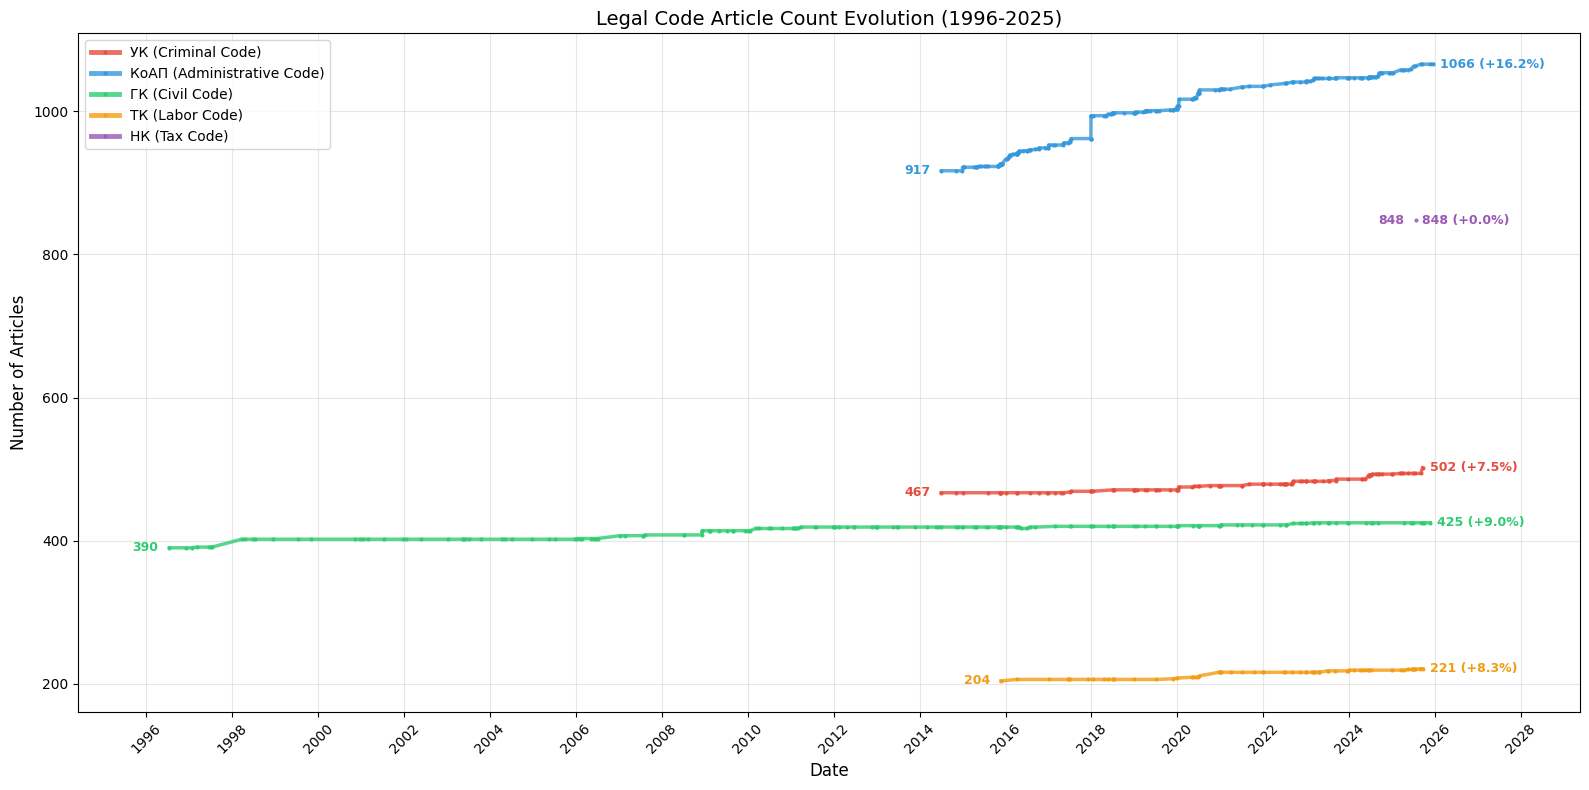

In [265]:
# Plot article count evolution over time
fig, ax = plt.subplots(figsize=(16, 8))

for code_key, code_info in CODES.items():
    code_versions = versions_df[versions_df['code_key'] == code_key].copy()
    
    if len(code_versions) > 0:
        ax.plot(
            code_versions['version_date'],
            code_versions['article_count'],
            marker='.',
            markersize=4,
            linewidth=2.5,
            color=code_info['color'],
            label=f"{code_info['short']} ({code_info['name_en']})",
            alpha=0.8
        )
        
        # Annotate starting count
        first_date = code_versions['version_date'].iloc[0]
        first_count = code_versions['article_count'].iloc[0]
        ax.annotate(f'{first_count}', xy=(first_date, first_count),
                   xytext=(-8, 0), textcoords='offset points',
                   fontsize=9, color=code_info['color'], fontweight='bold',
                   ha='right', va='center')
        
        # Annotate ending count with growth percentage
        last_date = code_versions['version_date'].iloc[-1]
        last_count = code_versions['article_count'].iloc[-1]
        growth_pct = ((last_count / first_count) - 1) * 100
        ax.annotate(f'{last_count} ({growth_pct:+.1f}%)', xy=(last_date, last_count),
                   xytext=(5, 0), textcoords='offset points',
                   fontsize=9, color=code_info['color'], fontweight='bold',
                   ha='left', va='center')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Legal Code Article Count Evolution (1996-2025)', fontsize=14)

# Format x-axis
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Extend x-axis to make room for annotations
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min - 0.02 * (x_max - x_min), x_max + 0.06 * (x_max - x_min))

# Legend with thicker lines
legend = ax.legend(loc='upper left', fontsize=10)
for line in legend.get_lines():
    line.set_linewidth(3.5)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "article_count_evolution.png", dpi=150, bbox_inches='tight')
plt.show()

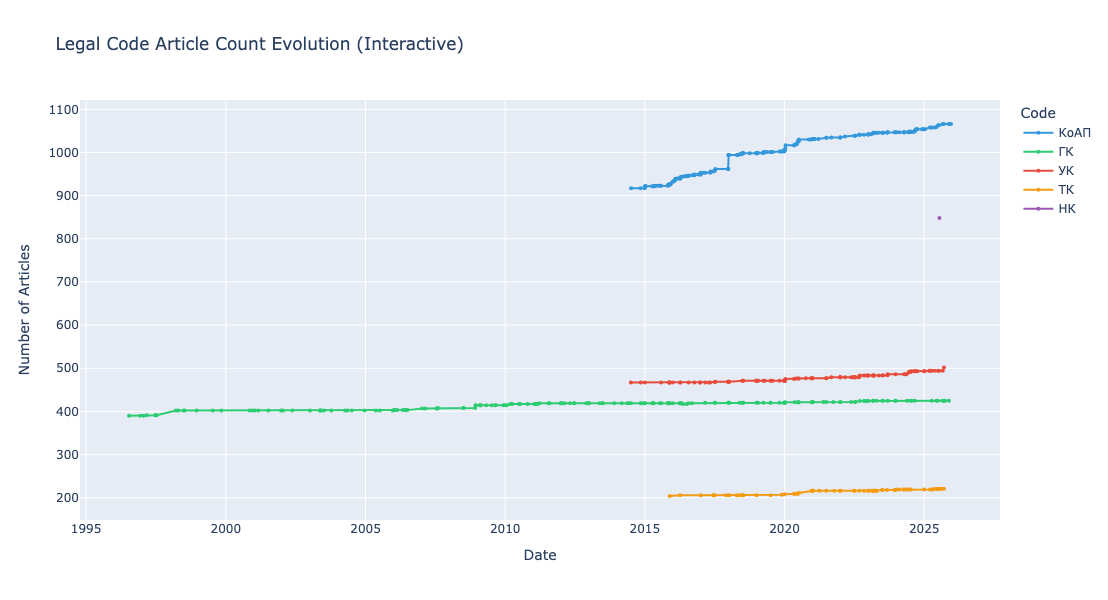

In [266]:
# Interactive plot with Plotly
fig = px.line(
    versions_df,
    x='version_date',
    y='article_count',
    color='code_short',
    color_discrete_map={info['short']: info['color'] for info in CODES.values()},
    title='Legal Code Article Count Evolution (Interactive)',
    labels={
        'version_date': 'Date',
        'article_count': 'Number of Articles',
        'code_short': 'Code'
    },
    hover_data=['version_number', 'version_status']
)

fig.update_traces(mode='lines+markers', marker=dict(size=4))
fig.update_layout(width=1200, height=600, hovermode='x unified')
fig.write_html(OUTPUT_DIR / "article_count_evolution_interactive.html")
fig.show()

In [267]:
# Calculate article count changes between versions
versions_df_sorted = versions_df.sort_values(['code_key', 'version_date']).copy()
versions_df_sorted['article_change'] = versions_df_sorted.groupby('code_key')['article_count'].diff()

# Show biggest changes
print("Biggest Article Count Changes (Top 20):")
print("=" * 80)

big_changes = versions_df_sorted.dropna(subset=['article_change'])
big_changes = big_changes.reindex(big_changes['article_change'].abs().sort_values(ascending=False).index)

for _, row in big_changes.head(20).iterrows():
    change = row['article_change']
    sign = '+' if change > 0 else ''
    print(f"{row['code_short']:6} | {row['version_date'].strftime('%Y-%m-%d')} | "
          f"v{row['version_number']:2} | {sign}{int(change):3} articles | "
          f"Total: {row['article_count']}")

Biggest Article Count Changes (Top 20):
КоАП   | 2017-12-28 | v73 | + 32 articles | Total: 994
ГК     | 1998-03-22 | v 8 | + 11 articles | Total: 402
КоАП   | 2020-01-16 | v116 | +  9 articles | Total: 1017
УК     | 2025-09-16 | v109 | +  8 articles | Total: 502
КоАП   | 2020-06-25 | v123 | +  6 articles | Total: 1025
ГК     | 2008-12-10 | v51 | +  6 articles | Total: 414
КоАП   | 2016-01-01 | v32 | +  6 articles | Total: 933
КоАП   | 2015-01-01 | v 4 | +  5 articles | Total: 922
ТК     | 2020-12-19 | v23 | +  5 articles | Total: 216
УК     | 2024-06-16 | v90 | +  5 articles | Total: 491
КоАП   | 2020-01-01 | v111 | +  4 articles | Total: 1007
КоАП   | 2020-07-07 | v128 | +  4 articles | Total: 1030
КоАП   | 2017-01-01 | v60 | +  4 articles | Total: 953
КоАП   | 2025-03-13 | v195 | +  4 articles | Total: 1058
КоАП   | 2025-07-01 | v200 | +  4 articles | Total: 1063
УК     | 2020-01-11 | v44 | +  4 articles | Total: 475
ГК     | 2007-01-12 | v43 | +  4 articles | Total: 407
УК     | 202

## 5. Amendment Frequency Analysis

In [268]:
# Extract year and month for frequency analysis
versions_df['year'] = versions_df['version_date'].dt.year
versions_df['month'] = versions_df['version_date'].dt.month
versions_df['year_month'] = versions_df['version_date'].dt.to_period('M')

# Amendments per year by code
yearly_amendments = versions_df.groupby(['year', 'code_short']).size().unstack(fill_value=0)

print("Amendments per Year by Code:\n")
yearly_amendments

Amendments per Year by Code:



code_short,ГК,КоАП,НК,ТК,УК
year,,,,,
1996,2,0,0,0,0
1997,5,0,0,0,0
1998,5,0,0,0,0
1999,2,0,0,0,0
2000,2,0,0,0,0
2001,4,0,0,0,0
2002,2,0,0,0,0
2003,6,0,0,0,0
2004,4,0,0,0,0


In [269]:
versions_df.head(4)

,code_key,code_short,code_color,version_number,version_date,version_status,article_count,filename,year,month,year_month
0,administrative,КоАП,#3498db,1,2014-07-05,Новый,917,version_001_2014-07-05.json,2014,7,2014-07
1,administrative,КоАП,#3498db,2,2014-11-07,Обновленный,917,version_002_2014-11-07.json,2014,11,2014-11
2,administrative,КоАП,#3498db,3,2014-12-29,Обновленный,917,version_003_2014-12-29.json,2014,12,2014-12
3,administrative,КоАП,#3498db,4,2015-01-01,Обновленный,922,version_004_2015-01-01.json,2015,1,2015-01


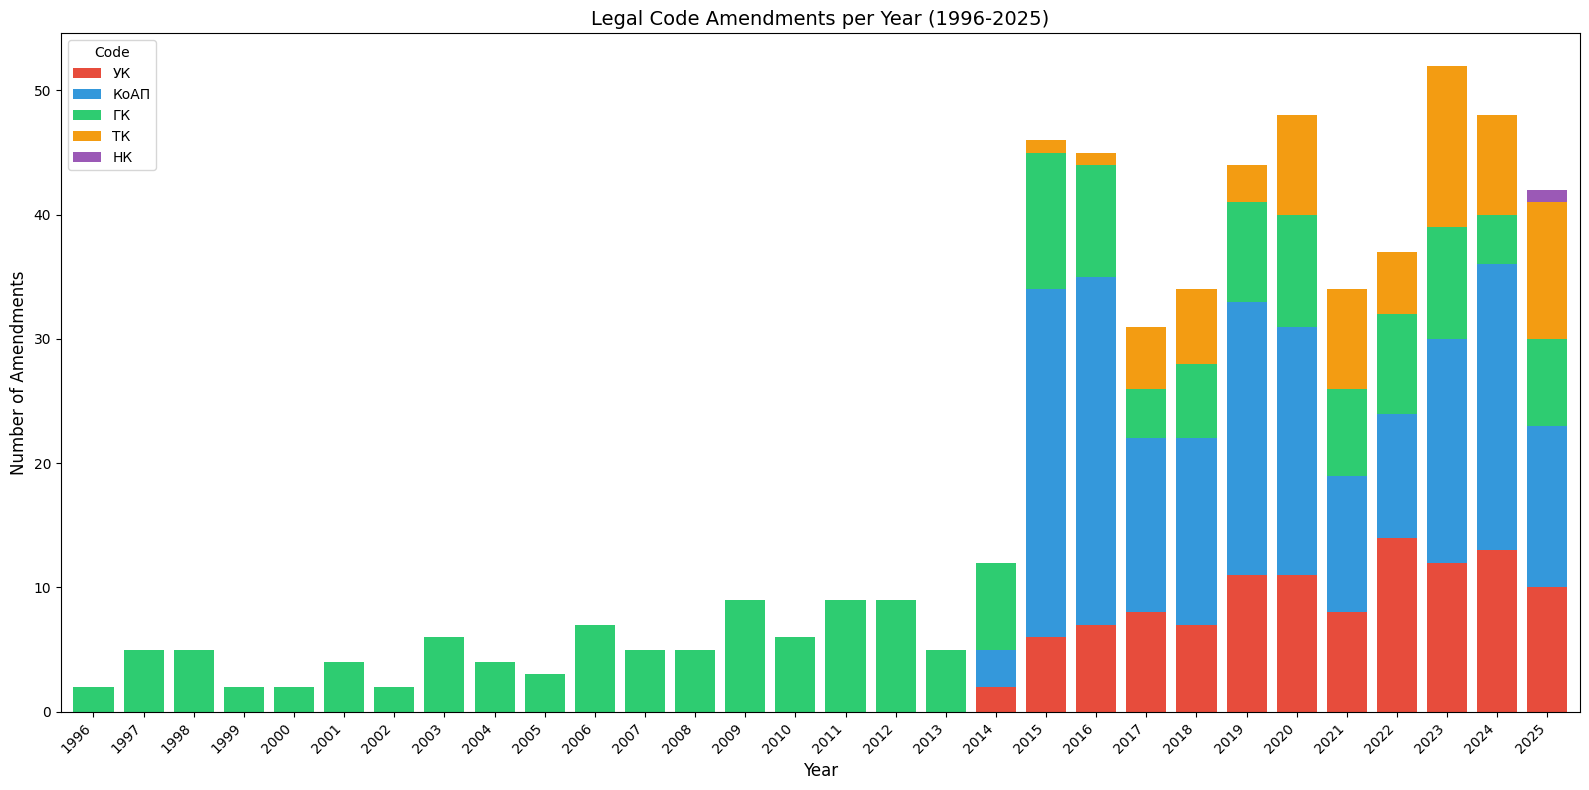

In [270]:
# Stacked bar chart of amendments per year
fig, ax = plt.subplots(figsize=(16, 8))

# Reorder columns to match our code order
code_order = [CODES[k]['short'] for k in CODES.keys()]
colors = [CODES[k]['color'] for k in CODES.keys()]

yearly_amendments_ordered = yearly_amendments[[c for c in code_order if c in yearly_amendments.columns]]

yearly_amendments_ordered.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[CODES[k]['color'] for k in CODES.keys() if CODES[k]['short'] in yearly_amendments_ordered.columns],
    width=0.8
)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Amendments', fontsize=12)
ax.set_title('Legal Code Amendments per Year (1996-2025)', fontsize=14)
ax.legend(title='Code', loc='upper left')

# Rotate x labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "amendments_per_year.png", dpi=150, bbox_inches='tight')
plt.show()

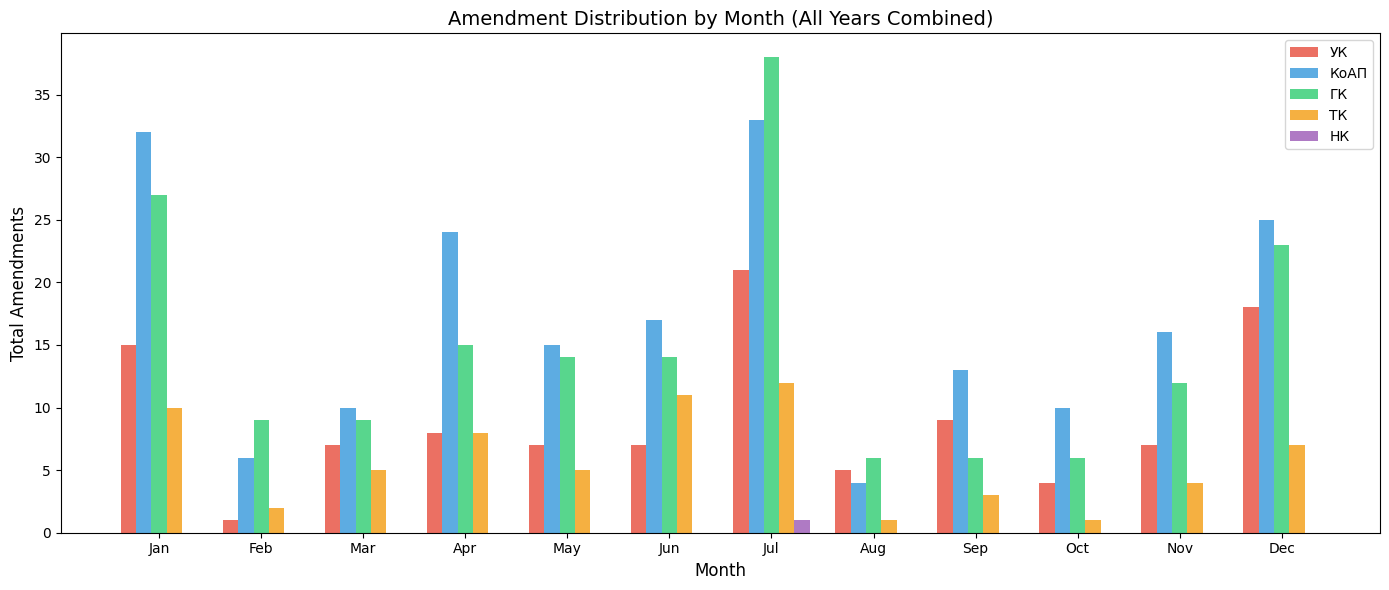

In [271]:
# Monthly distribution of amendments (seasonal patterns)
monthly_dist = versions_df.groupby(['month', 'code_short']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot each code
x = np.arange(12)
width = 0.15

for i, (code_key, code_info) in enumerate(CODES.items()):
    if code_info['short'] in monthly_dist.columns:
        values = monthly_dist[code_info['short']].values
        ax.bar(x + i * width, values, width, 
               label=code_info['short'], color=code_info['color'], alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Amendments', fontsize=12)
ax.set_title('Amendment Distribution by Month (All Years Combined)', fontsize=14)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(month_names)
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "amendments_by_month.png", dpi=150, bbox_inches='tight')
plt.show()

In [272]:
# Days between amendments
versions_df_sorted = versions_df.sort_values(['code_key', 'version_date']).copy()
versions_df_sorted['days_since_last'] = versions_df_sorted.groupby('code_key')['version_date'].diff().dt.days

# Statistics
print("Days Between Amendments:")
print("=" * 60)

for code_key, code_info in CODES.items():
    code_data = versions_df_sorted[versions_df_sorted['code_key'] == code_key]['days_since_last'].dropna()
    
    if len(code_data) > 0:
        print(f"\n{code_info['short']} ({code_info['name_en']}):")
        print(f"  Mean: {code_data.mean():.1f} days ({code_data.mean()/30:.1f} months)")
        print(f"  Median: {code_data.median():.1f} days")
        print(f"  Min: {code_data.min():.0f} days")
        print(f"  Max: {code_data.max():.0f} days ({code_data.max()/365:.1f} years)")

Days Between Amendments:

УК (Criminal Code):
  Mean: 37.9 days (1.3 months)
  Median: 16.0 days
  Min: 1 days
  Max: 213 days (0.6 years)

КоАП (Administrative Code):
  Mean: 20.5 days (0.7 months)
  Median: 9.0 days
  Min: 1 days
  Max: 167 days (0.5 years)

ГК (Civil Code):
  Mean: 60.2 days (2.0 months)
  Median: 38.0 days
  Min: 1 days
  Max: 370 days (1.0 years)

ТК (Labor Code):
  Mean: 52.7 days (1.8 months)
  Median: 28.5 days
  Min: 1 days
  Max: 270 days (0.7 years)


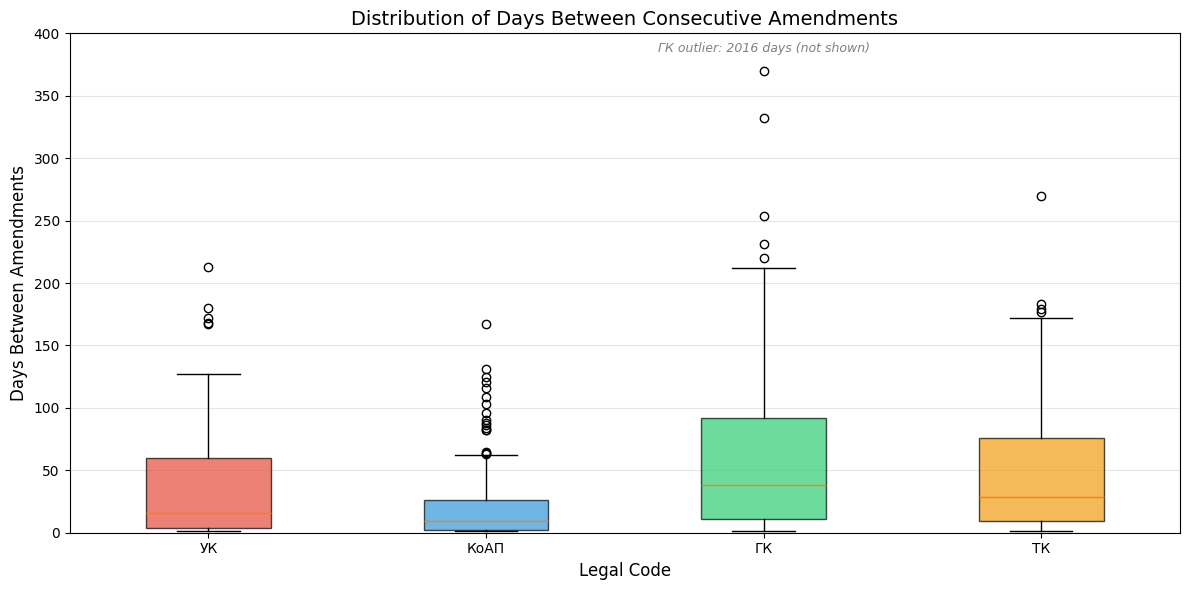

In [273]:
# Box plot of days between amendments
fig, ax = plt.subplots(figsize=(12, 6))

data_for_boxplot = []
labels = []
colors_list = []

for code_key, code_info in CODES.items():
    code_data = versions_df_sorted[versions_df_sorted['code_key'] == code_key]['days_since_last'].dropna()
    if len(code_data) > 0:
        data_for_boxplot.append(code_data.values)
        labels.append(code_info['short'])
        colors_list.append(code_info['color'])

bp = ax.boxplot(data_for_boxplot, labels=labels, patch_artist=True)

for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Days Between Amendments', fontsize=12)
ax.set_xlabel('Legal Code', fontsize=12)
ax.set_title('Distribution of Days Between Consecutive Amendments', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

# Cap y-axis to show detail; ГК has outlier at 2016 days (5.5 year gap 2002-2007)
ax.set_ylim(0, 400)
ax.annotate('ГК outlier: 2016 days (not shown)', xy=(3, 385), fontsize=9, 
            ha='center', style='italic', color='gray')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "days_between_amendments.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Version Timeline Visualization

## 5.5 Per-Code Growth Rate Over Time

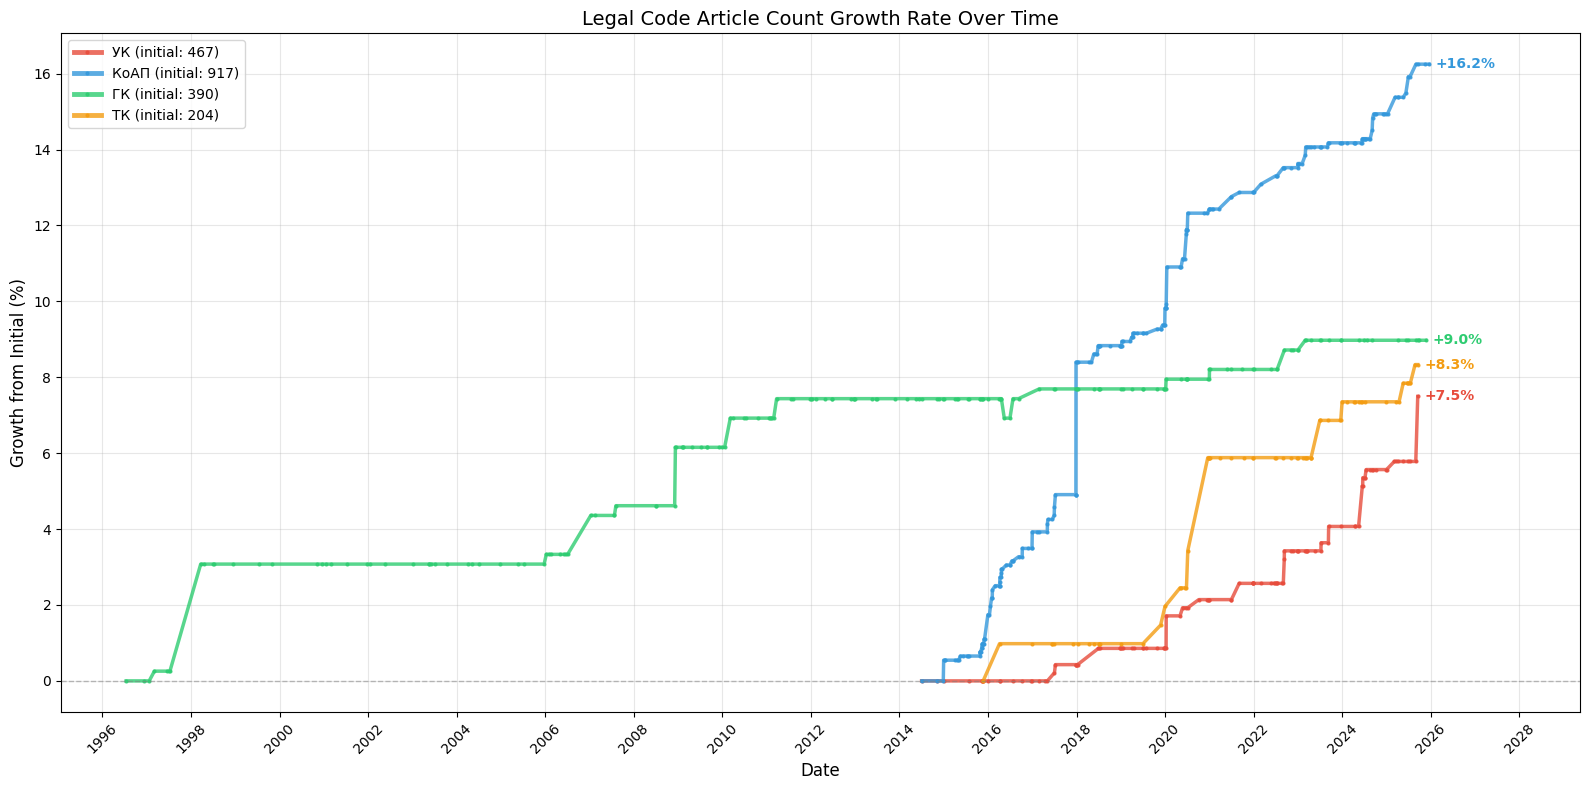


Growth Rate Summary:
УК     | Initial:  467 → Current:  502 | Growth: +7.5%
КоАП   | Initial:  917 → Current: 1066 | Growth: +16.2%
ГК     | Initial:  390 → Current:  425 | Growth: +9.0%
ТК     | Initial:  204 → Current:  221 | Growth: +8.3%


In [280]:
# Calculate percentage growth over time relative to initial article count
fig, ax = plt.subplots(figsize=(16, 8))

for code_key, code_info in CODES.items():
    code_versions = versions_df[versions_df['code_key'] == code_key].copy()
    
    if len(code_versions) > 1:  # Need at least 2 versions for growth
        code_versions = code_versions.sort_values('version_date')
        initial_count = code_versions.iloc[0]['article_count']
        
        # Calculate % growth from initial
        code_versions['growth_pct'] = ((code_versions['article_count'] / initial_count) - 1) * 100
        
        ax.plot(
            code_versions['version_date'],
            code_versions['growth_pct'],
            marker='.',
            markersize=4,
            linewidth=2.5,
            color=code_info['color'],
            label=f"{code_info['short']} (initial: {initial_count})",
            alpha=0.8
        )
        
        # Annotate final growth percentage
        last_date = code_versions['version_date'].iloc[-1]
        last_growth = code_versions['growth_pct'].iloc[-1]
        ax.annotate(f'{last_growth:+.1f}%', xy=(last_date, last_growth),
                   xytext=(5, 0), textcoords='offset points',
                   fontsize=10, color=code_info['color'], fontweight='bold',
                   ha='left', va='center')

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Growth from Initial (%)', fontsize=12)
ax.set_title('Legal Code Article Count Growth Rate Over Time', fontsize=14)

# Format x-axis
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Extend x-axis for annotations
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + 0.06 * (x_max - x_min))

legend = ax.legend(loc='upper left', fontsize=10)
for line in legend.get_lines():
    line.set_linewidth(3.5)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "growth_rate_over_time.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nGrowth Rate Summary:")
print("=" * 60)
for code_key, code_info in CODES.items():
    code_versions = versions_df[versions_df['code_key'] == code_key]
    if len(code_versions) > 1:
        initial = code_versions.iloc[0]['article_count']
        current = code_versions.iloc[-1]['article_count']
        growth = ((current / initial) - 1) * 100
        print(f"{code_info['short']:6} | Initial: {initial:4} → Current: {current:4} | Growth: {growth:+.1f}%")

## 5.6 Burst Amendments Detection

Identify dates with unusually high article changes (statistical outliers).

In [286]:
# Calculate article changes and identify bursts (statistical outliers)
versions_df_sorted = versions_df.sort_values(['code_key', 'version_date']).copy()
versions_df_sorted['article_change'] = versions_df_sorted.groupby('code_key')['article_count'].diff()

# Remove NaN (first version of each code)
changes_df = versions_df_sorted.dropna(subset=['article_change']).copy()
changes_df['abs_change'] = changes_df['article_change'].abs()

# Calculate statistics for burst detection
mean_change = changes_df['abs_change'].mean()
std_change = changes_df['abs_change'].std()
threshold_2sd = mean_change + 2 * std_change  # 2 standard deviations
threshold_3sd = mean_change + 3 * std_change  # 3 standard deviations (extreme)

print("Burst Amendment Detection")
print("=" * 80)
print(f"Statistics for absolute article changes:")
print(f"  Mean: {mean_change:.2f} articles")
print(f"  Std:  {std_change:.2f} articles")
print(f"  Threshold (2σ): {threshold_2sd:.1f} articles")
print(f"  Threshold (3σ): {threshold_3sd:.1f} articles")

Burst Amendment Detection
Statistics for absolute article changes:
  Mean: 0.43 articles
  Std:  1.74 articles
  Threshold (2σ): 3.9 articles
  Threshold (3σ): 5.7 articles


In [290]:
# Identify burst amendments (>2 std deviations)
bursts = changes_df[changes_df['abs_change'] >= threshold_2sd].sort_values('abs_change', ascending=False)

print(f"\n{'='*80}")
print(f"BURST AMENDMENTS (>{threshold_2sd:.0f} articles change, 2σ threshold)")
print("=" * 80)
print(f"Found {len(bursts)} burst amendments:")


BURST AMENDMENTS (>4 articles change, 2σ threshold)
Found 17 burst amendments:


In [291]:
# Create DataFrame for nice display
burst_display = bursts[['code_short', 'version_date', 'version_number', 'article_change', 'article_count', 'abs_change']].copy()
burst_display['Date'] = burst_display['version_date'].dt.strftime('%Y-%m-%d')
burst_display['Version'] = 'v' + burst_display['version_number'].astype(str)
burst_display['Change'] = burst_display['article_change'].apply(lambda x: f"+{int(x)}" if x > 0 else str(int(x)))
burst_display['Total'] = burst_display['article_count'].astype(int)
burst_display['Severity'] = burst_display['abs_change'].apply(lambda x: "EXTREME" if x >= threshold_3sd else "HIGH")

burst_table = burst_display[['code_short', 'Date', 'Version', 'Change', 'Total', 'Severity']].rename(
    columns={'code_short': 'Code'}
)
burst_table

,Code,Date,Version,Change,Total,Severity
72,КоАП,2017-12-28,v73,+32,994,EXTREME
212,ГК,1998-03-22,v8,+11,402,EXTREME
115,КоАП,2020-01-16,v116,+9,1017,EXTREME
492,УК,2025-09-16,v109,+8,502,EXTREME
122,КоАП,2020-06-25,v123,+6,1025,EXTREME
31,КоАП,2016-01-01,v32,+6,933,EXTREME
255,ГК,2008-12-10,v51,+6,414,EXTREME
3,КоАП,2015-01-01,v4,+5,922,HIGH
473,УК,2024-06-16,v90,+5,491,HIGH
515,ТК,2020-12-19,v23,+5,216,HIGH


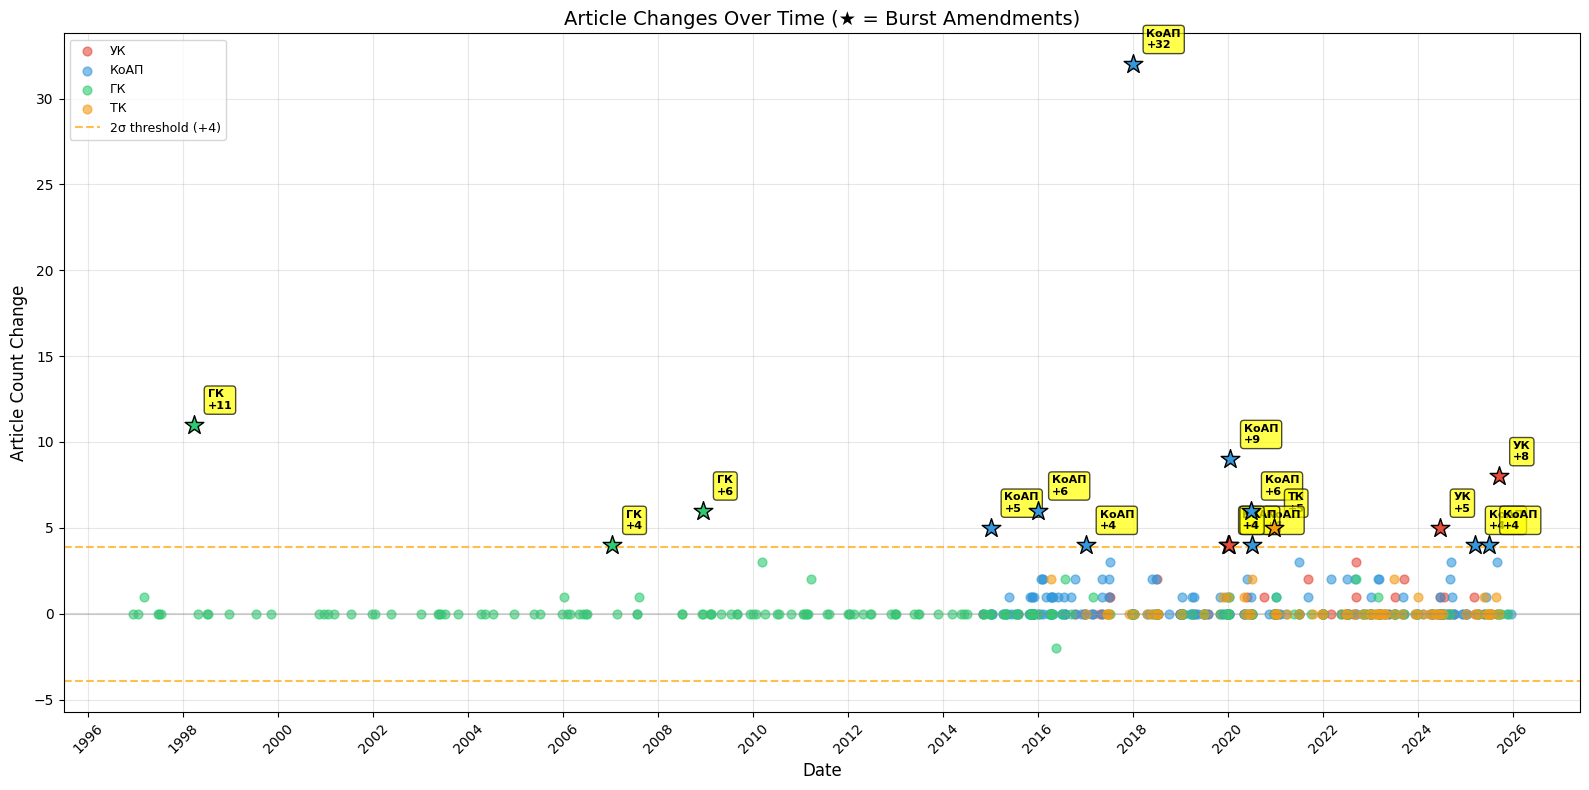

In [292]:
# Visualize bursts on timeline
fig, ax = plt.subplots(figsize=(16, 8))

# Plot all changes as scatter
for code_key, code_info in CODES.items():
    code_changes = changes_df[changes_df['code_key'] == code_key]
    if len(code_changes) > 0:
        ax.scatter(
            code_changes['version_date'],
            code_changes['article_change'],
            color=code_info['color'],
            alpha=0.6,
            s=40,
            label=code_info['short']
        )

# Highlight bursts with larger markers
burst_colors = {'УК': '#e74c3c', 'КоАП': '#3498db', 'ГК': '#2ecc71', 'ТК': '#f39c12'}
for _, row in bursts.iterrows():
    ax.scatter(
        row['version_date'],
        row['article_change'],
        color=burst_colors.get(row['code_short'], 'black'),
        s=200,
        marker='*',
        edgecolors='black',
        linewidths=1,
        zorder=5
    )
    # Annotate burst
    ax.annotate(
        f"{row['code_short']}\n{int(row['article_change']):+d}",
        xy=(row['version_date'], row['article_change']),
        xytext=(10, 10 if row['article_change'] > 0 else -10),
        textcoords='offset points',
        fontsize=8,
        fontweight='bold',
        ha='left',
        va='bottom' if row['article_change'] > 0 else 'top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7)
    )

# Add threshold lines
ax.axhline(y=threshold_2sd, color='orange', linestyle='--', alpha=0.7, label=f'2σ threshold (+{threshold_2sd:.0f})')
ax.axhline(y=-threshold_2sd, color='orange', linestyle='--', alpha=0.7)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Article Count Change', fontsize=12)
ax.set_title('Article Changes Over Time (★ = Burst Amendments)', fontsize=14)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "burst_amendments.png", dpi=150, bbox_inches='tight')
plt.show()

In [296]:
# Summary by code
print("BURST SUMMARY BY CODE")
print("=" * 80)
burst_summary = bursts.groupby('code_short').agg({
    'article_change': ['count', 'sum', 'mean', 'max']
}).round(1)
burst_summary.columns = ['Count', 'Total Change', 'Avg Change', 'Max Change']
burst_summary

BURST SUMMARY BY CODE


,Count,Total Change,Avg Change,Max Change
code_short,,,,
ГК,3,21.0,7.0,11.0
КоАП,10,78.0,7.8,32.0
ТК,1,5.0,5.0,5.0
УК,3,17.0,5.7,8.0


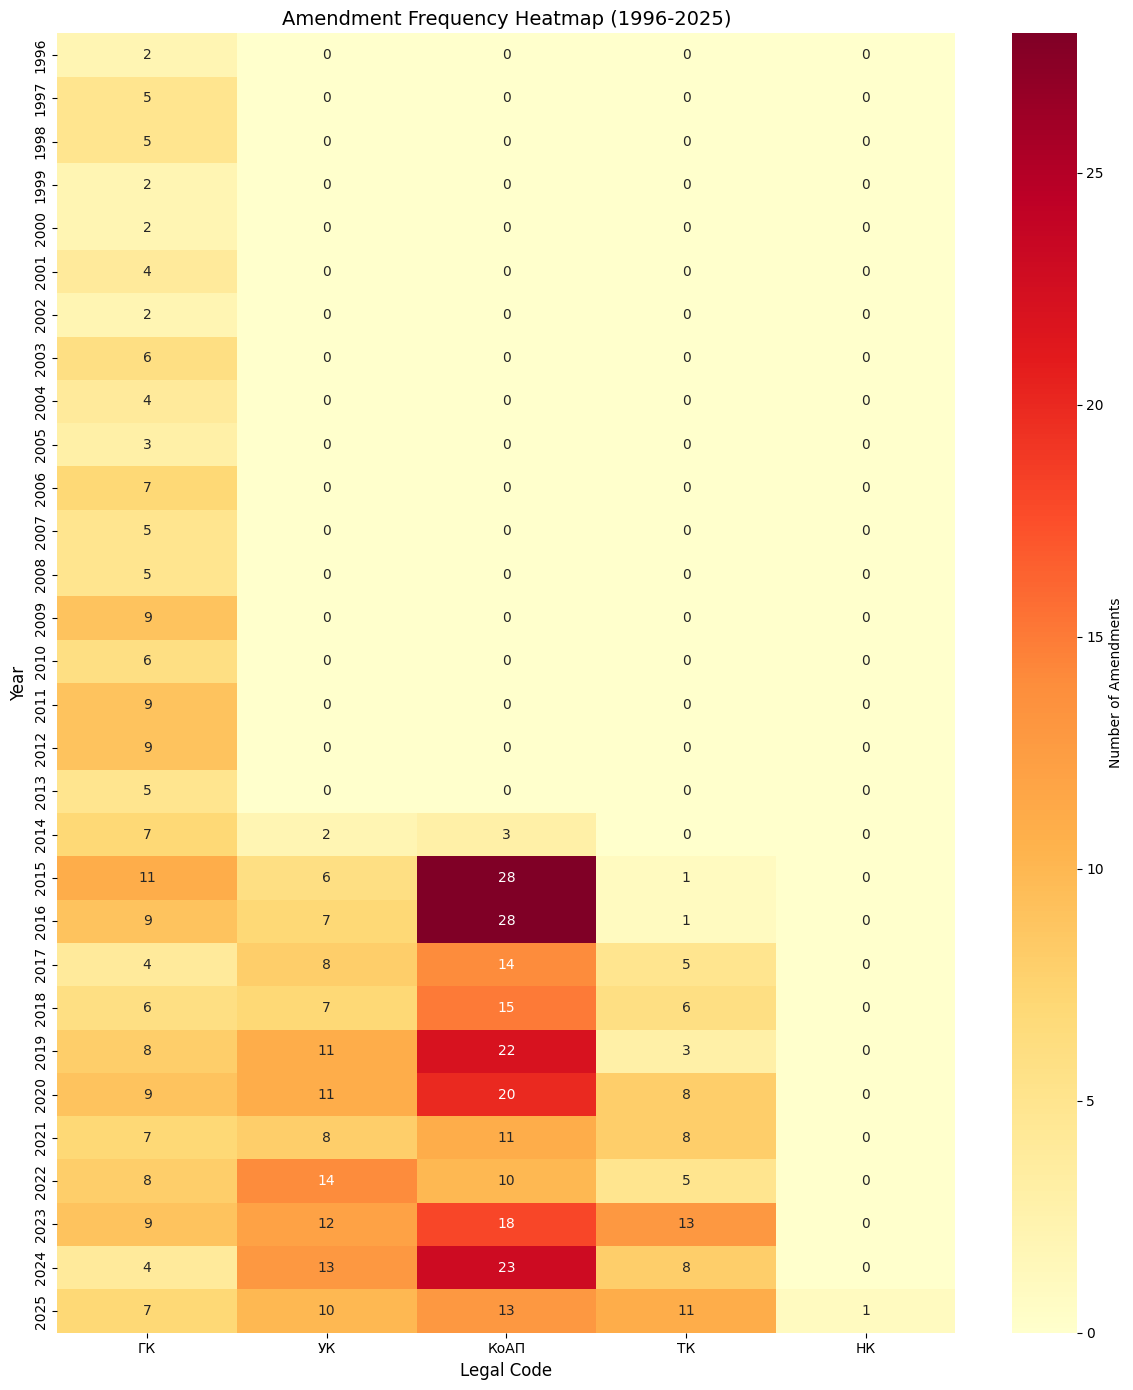

In [297]:
# Heatmap of amendments by year and code
pivot_data = versions_df.pivot_table(
    index='year',
    columns='code_short',
    values='version_number',
    aggfunc='count',
    fill_value=0
)

# Reorder columns
code_order = ['ГК', 'УК', 'КоАП', 'ТК', 'НК']
pivot_data = pivot_data[[c for c in code_order if c in pivot_data.columns]]

fig, ax = plt.subplots(figsize=(12, 14))

sns.heatmap(
    pivot_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Number of Amendments'}
)

ax.set_xlabel('Legal Code', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.set_title('Amendment Frequency Heatmap (1996-2025)', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "amendment_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Cross-Code Amendment Synchronization

In [298]:
# Find dates where multiple codes were amended together
amendment_dates = versions_df.groupby('version_date')['code_short'].apply(list).reset_index()
amendment_dates['num_codes'] = amendment_dates['code_short'].apply(len)

# Find synchronized amendments (2+ codes on same day)
sync_amendments = amendment_dates[amendment_dates['num_codes'] >= 2].sort_values('num_codes', ascending=False)

print("Synchronized Amendments (Multiple Codes on Same Day):")
print("=" * 70)
print(f"Total dates with 2+ codes amended: {len(sync_amendments)}")
print(f"\nTop synchronized amendment dates:")

for _, row in sync_amendments.head(20).iterrows():
    codes_str = ', '.join(row['code_short'])
    print(f"{row['version_date'].strftime('%Y-%m-%d')} | {row['num_codes']} codes | {codes_str}")

Synchronized Amendments (Multiple Codes on Same Day):
Total dates with 2+ codes amended: 135

Top synchronized amendment dates:
2021-07-01 | 4 codes | КоАП, ГК, УК, ТК
2023-03-07 | 4 codes | КоАП, ГК, УК, ТК
2020-01-01 | 4 codes | КоАП, ГК, УК, ТК
2018-07-02 | 4 codes | КоАП, ГК, УК, ТК
2019-01-01 | 4 codes | КоАП, ГК, УК, ТК
2019-07-03 | 4 codes | КоАП, ГК, УК, ТК
2018-01-10 | 4 codes | КоАП, ГК, УК, ТК
2022-11-05 | 4 codes | КоАП, ГК, УК, ТК
2021-01-02 | 4 codes | КоАП, ГК, УК, ТК
2024-06-16 | 3 codes | КоАП, УК, ТК
2023-12-23 | 3 codes | КоАП, ГК, УК
2015-01-01 | 3 codes | КоАП, ГК, УК
2015-08-02 | 3 codes | КоАП, ГК, УК
2014-11-07 | 3 codes | КоАП, ГК, УК
2024-04-15 | 3 codes | КоАП, УК, ТК
2023-09-12 | 3 codes | КоАП, ГК, УК
2018-05-24 | 3 codes | КоАП, ГК, ТК
2019-12-26 | 3 codes | КоАП, ГК, УК
2019-01-21 | 3 codes | КоАП, ГК, УК
2018-01-01 | 3 codes | КоАП, ГК, УК


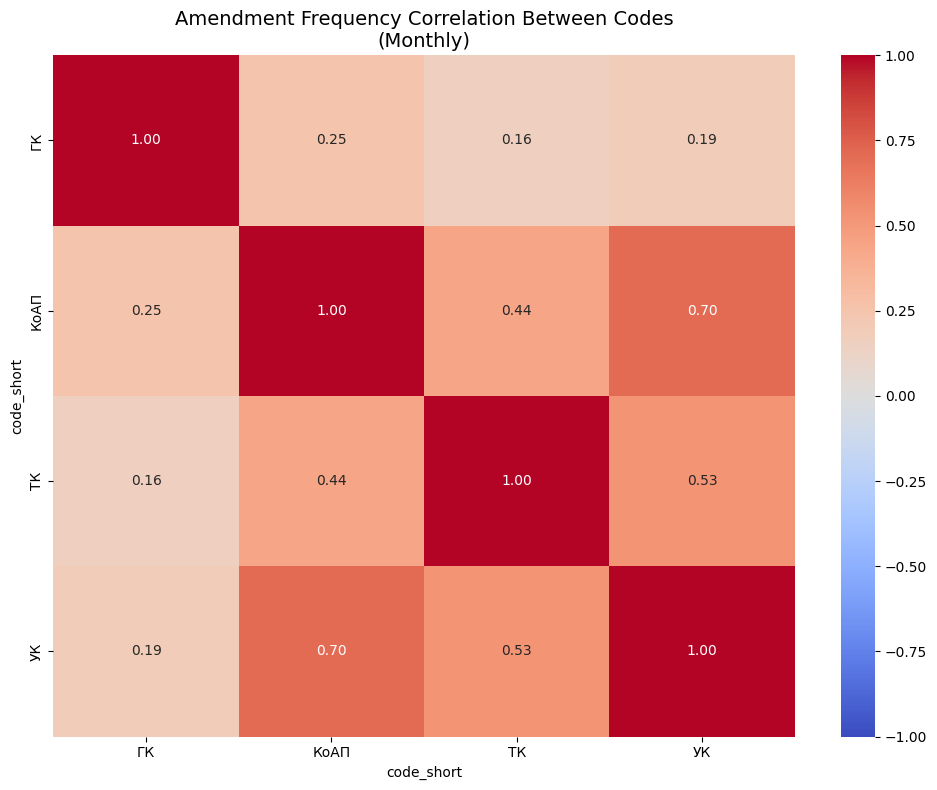


Interpretation:
- Positive correlation: codes tend to be amended together
- Negative correlation: codes are amended at different times


In [276]:
# Correlation between amendment frequencies (by month)
monthly_counts = versions_df.groupby(['year_month', 'code_short']).size().unstack(fill_value=0)

# Only use codes with enough data
valid_codes = [c for c in monthly_counts.columns if monthly_counts[c].sum() > 10]
monthly_counts = monthly_counts[valid_codes]

# Compute correlation
corr_matrix = monthly_counts.corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    vmin=-1,
    vmax=1
)

ax.set_title('Amendment Frequency Correlation Between Codes\n(Monthly)', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "amendment_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- Positive correlation: codes tend to be amended together")
print("- Negative correlation: codes are amended at different times")

## 8. Build Consolidated Version Index

In [277]:
# Create a consolidated index for downstream analysis
consolidated_index = {
    'generated_at': datetime.now().isoformat(),
    'total_versions': len(versions_df),
    'date_range': {
        'earliest': versions_df['version_date'].min().strftime('%Y-%m-%d'),
        'latest': versions_df['version_date'].max().strftime('%Y-%m-%d')
    },
    'codes': {}
}

for code_key, code_info in CODES.items():
    code_versions = versions_df[versions_df['code_key'] == code_key]
    
    if len(code_versions) > 0:
        consolidated_index['codes'][code_key] = {
            'short': code_info['short'],
            'name_ru': code_info['name_ru'],
            'name_en': code_info['name_en'],
            'folder': code_info['folder'],
            'doc_id': code_info['doc_id'],
            'total_versions': len(code_versions),
            'date_range': {
                'first': code_versions['version_date'].min().strftime('%Y-%m-%d'),
                'last': code_versions['version_date'].max().strftime('%Y-%m-%d')
            },
            'article_count': {
                'initial': int(code_versions.iloc[0]['article_count']),
                'current': int(code_versions.iloc[-1]['article_count']),
                'min': int(code_versions['article_count'].min()),
                'max': int(code_versions['article_count'].max())
            }
        }

# Save consolidated index
with open(OUTPUT_DIR / 'consolidated_version_index.json', 'w', encoding='utf-8') as f:
    json.dump(consolidated_index, f, ensure_ascii=False, indent=2)

print("Consolidated index saved to output/08/consolidated_version_index.json")
print(json.dumps(consolidated_index, indent=2, ensure_ascii=False)[:2000] + "...")

Consolidated index saved to output/08/consolidated_version_index.json
{
  "generated_at": "2026-01-10T18:33:31.813068",
  "total_versions": 563,
  "date_range": {
    "earliest": "1996-07-15",
    "latest": "2025-12-17"
  },
  "codes": {
    "criminal": {
      "short": "УК",
      "name_ru": "Уголовный кодекс",
      "name_en": "Criminal Code",
      "folder": "K1400000226_rus_ugolov",
      "doc_id": "K1400000226",
      "total_versions": 109,
      "date_range": {
        "first": "2014-07-03",
        "last": "2025-09-16"
      },
      "article_count": {
        "initial": 467,
        "current": 502,
        "min": 467,
        "max": 502
      }
    },
    "administrative": {
      "short": "КоАП",
      "name_ru": "Кодекс об административных правонарушениях",
      "name_en": "Administrative Code",
      "folder": "K1400000235_rus_adm",
      "doc_id": "K1400000235",
      "total_versions": 205,
      "date_range": {
        "first": "2014-07-05",
        "last": "2025-12-17"
 

In [278]:
# Export version timeline data
export_df = versions_df.copy()
export_df['version_date_str'] = export_df['version_date'].dt.strftime('%Y-%m-%d')
export_df['year_month_str'] = export_df['year_month'].astype(str)

export_cols = ['code_key', 'code_short', 'version_number', 'version_date_str', 
               'version_status', 'article_count', 'filename', 'year', 'month']

export_df[export_cols].to_csv(OUTPUT_DIR / 'version_timeline.csv', index=False)
print(f"Exported {len(export_df)} version records to output/08/version_timeline.csv")

Exported 563 version records to output/08/version_timeline.csv


## 9. Summary

In [300]:
print("=" * 80)
print("KEY FINDINGS - Historical Overview Analysis")
print("=" * 80)

total_versions = len(versions_df)
earliest_date = versions_df['version_date'].min()
latest_date = versions_df['version_date'].max()
years_covered = (latest_date - earliest_date).days / 365.25

print(f"""
   DATA SCOPE:
   ─────────────────────────────────────────────────────────────────────
   Total versions analyzed:  {total_versions}
   Date range:               {earliest_date.strftime('%Y-%m-%d')} to {latest_date.strftime('%Y-%m-%d')}
   Years covered:            {years_covered:.1f} years
""")

print("=" * 80)
print("1. VERSION COUNTS PER CODE")
print("=" * 80)
print(f"""
   Code   | Versions | First Date  | Last Date   | Years Span
   ───────┼──────────┼─────────────┼─────────────┼───────────""")

for code_key, code_info in CODES.items():
    code_versions = versions_df[versions_df['code_key'] == code_key]
    if len(code_versions) > 0:
        first = code_versions['version_date'].min()
        last = code_versions['version_date'].max()
        span = (last - first).days / 365.25
        print(f"   {code_info['short']:6} | {len(code_versions):8} | {first.strftime('%Y-%m-%d')} | {last.strftime('%Y-%m-%d')} | {span:5.1f}")

print("\n" + "=" * 80)
print("2. ARTICLE COUNT EVOLUTION")
print("=" * 80)
print(f"""
   Code   | Initial | Current | Min  | Max  | Growth
   ───────┼─────────┼─────────┼──────┼──────┼────────""")

for code_key, code_info in CODES.items():
    code_versions = versions_df[versions_df['code_key'] == code_key]
    if len(code_versions) > 0:
        initial = code_versions.iloc[0]['article_count']
        current = code_versions.iloc[-1]['article_count']
        min_art = code_versions['article_count'].min()
        max_art = code_versions['article_count'].max()
        growth = ((current / initial) - 1) * 100 if initial > 0 else 0
        print(f"   {code_info['short']:6} | {initial:7} | {current:7} | {min_art:4} | {max_art:4} | {growth:+6.1f}%")

# Find largest single change
versions_df_calc = versions_df.sort_values(['code_key', 'version_date']).copy()
versions_df_calc['article_change'] = versions_df_calc.groupby('code_key')['article_count'].diff()
max_change_idx = versions_df_calc['article_change'].abs().idxmax()
max_change_row = versions_df_calc.loc[max_change_idx]

print(f"""
   Largest single change: {max_change_row['code_short']} on {max_change_row['version_date'].strftime('%Y-%m-%d')}
                          {int(max_change_row['article_change']):+d} articles (v{max_change_row['version_number']})
""")

print("=" * 80)
print("3. AMENDMENT FREQUENCY")
print("=" * 80)

# Most active year
yearly_totals = versions_df.groupby('year').size()
most_active_year = yearly_totals.idxmax()
most_active_count = yearly_totals.max()

# Peak months
monthly_totals = versions_df.groupby('month').size()
top_months = monthly_totals.nlargest(2)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Recalculate days_since_last for this cell
versions_df_days = versions_df.sort_values(['code_key', 'version_date']).copy()
versions_df_days['days_since_last'] = versions_df_days.groupby('code_key')['version_date'].diff().dt.days

print(f"""
   Most active year:   {most_active_year} ({most_active_count} amendments across all codes)
   Peak months:        {month_names[top_months.index[0]-1]} ({top_months.iloc[0]} total), {month_names[top_months.index[1]-1]} ({top_months.iloc[1]} total)
   
   Days Between Amendments (by code):
   ─────────────────────────────────────────────────────────────────────
   Code   | Median | Mean  | Max Gap (days)
   ───────┼────────┼───────┼───────────────""")

for code_key in ['administrative', 'criminal', 'labor', 'civil']:
    code_info = CODES[code_key]
    code_data = versions_df_days[versions_df_days['code_key'] == code_key]['days_since_last'].dropna()
    if len(code_data) > 0:
        median_d = code_data.median()
        mean_d = code_data.mean()
        max_d = code_data.max()
        print(f"   {code_info['short']:6} | {median_d:6.0f} | {mean_d:5.1f} | {max_d:6.0f} ({max_d/365:.1f} years)")

print("\n" + "=" * 80)
print("4. SYNCHRONIZED AMENDMENTS")
print("=" * 80)

# Recalculate sync stats
sync_2plus = len(sync_amendments)
sync_3plus = len(sync_amendments[sync_amendments['num_codes'] >= 3])
sync_4 = len(sync_amendments[sync_amendments['num_codes'] == 4])

print(f"""
   Dates with 2+ codes amended:   {sync_2plus}
   Dates with 3+ codes amended:   {sync_3plus}
   Dates with 4 codes amended:    {sync_4}
   
   Recent 4-code synchronized amendments:
   ─────────────────────────────────────────────────────────────────────""")

for _, row in sync_amendments[sync_amendments['num_codes'] == 4].head(5).iterrows():
    codes_str = ', '.join(sorted(row['code_short']))
    print(f"   {row['version_date'].strftime('%Y-%m-%d')} | {codes_str}")

print("\n" + "=" * 80)
print("5. AMENDMENT CORRELATION")
print("=" * 80)

# Get correlation values
corr_pairs = []
codes_in_corr = [c for c in ['ГК', 'УК', 'КоАП', 'ТК'] if c in corr_matrix.columns]
for i, c1 in enumerate(codes_in_corr):
    for c2 in codes_in_corr[i+1:]:
        corr_pairs.append((c1, c2, corr_matrix.loc[c1, c2]))

corr_pairs.sort(key=lambda x: x[2], reverse=True)

print(f"""
   Monthly amendment correlation (higher = amended together):
   ─────────────────────────────────────────────────────────────────────""")
for c1, c2, corr in corr_pairs:
    print(f"   {c1} ↔ {c2}: {corr:.3f}")

highest_corr = corr_pairs[0]
print(f"""
   
   Highest correlation: {highest_corr[0]} ↔ {highest_corr[1]} ({highest_corr[2]:.3f})
   → These codes tend to be amended together (coordinated reforms)
""")

print("=" * 80)
print("6. BURST AMENDMENTS")
print("=" * 80)
print(f"""
   Burst detection threshold (2σ): {threshold_2sd:.1f} articles
   Burst amendments found: {len(bursts)}
   
   Largest burst: {bursts.iloc[0]['code_short']} on {bursts.iloc[0]['version_date'].strftime('%Y-%m-%d')}
                  {int(bursts.iloc[0]['article_change']):+d} articles
""")

print("=" * 80)
print("7. KEY OBSERVATIONS")
print("=" * 80)

# Calculate КоАП avg amendments
koap_data = versions_df[versions_df['code_key'] == 'administrative']
koap_years = (koap_data['version_date'].max() - koap_data['version_date'].min()).days / 365.25
koap_avg = len(koap_data) / koap_years if koap_years > 0 else 0

# ГК history
gk_data = versions_df[versions_df['code_key'] == 'civil']
gk_years = (gk_data['version_date'].max() - gk_data['version_date'].min()).days / 365.25

# Max gap
max_gap_data = []
for code_key in CODES:
    code_gaps = versions_df_days[versions_df_days['code_key'] == code_key]['days_since_last'].dropna()
    if len(code_gaps) > 0:
        max_gap_data.append((CODES[code_key]['short'], code_gaps.max()))
max_gap_data.sort(key=lambda x: x[1], reverse=True)
max_gap_code, max_gap_days = max_gap_data[0]

# Growth leader
growth_data = []
for code_key, code_info in CODES.items():
    code_versions = versions_df[versions_df['code_key'] == code_key]
    if len(code_versions) > 0:
        initial = code_versions.iloc[0]['article_count']
        current = code_versions.iloc[-1]['article_count']
        growth = ((current / initial) - 1) * 100 if initial > 0 else 0
        growth_data.append((code_info['short'], growth))
growth_data.sort(key=lambda x: x[1], reverse=True)

print(f"""
   LEGISLATIVE ACTIVITY:
   • КоАП is most frequently amended: {len(koap_data)} versions, avg. {koap_avg:.0f}/year since 2014
   • ГК has longest history: {len(gk_data)} versions over {gk_years:.0f} years (since 1996)
   • НК has only {len(versions_df[versions_df['code_key'] == 'tax'])} version (new code from 2025)
   
   AMENDMENT TIMING:
   • Peak legislative activity in {month_names[top_months.index[0]-1]} and {month_names[top_months.index[1]-1]}
   • {sync_4} dates with all 4 main codes amended simultaneously
   • Longest gap between amendments: {max_gap_code} ({max_gap_days:.0f} days / {max_gap_days/365:.1f} years)
   
   CODE GROWTH:
   • All codes show growth over time
   • Growth leader: {growth_data[0][0]} ({growth_data[0][1]:+.1f}%)
   • Second: {growth_data[1][0]} ({growth_data[1][1]:+.1f}%)
   
   BURST AMENDMENTS:
   • {len(bursts)} statistical outliers detected (>2σ article changes)
   • Largest: КоАП 2017-12-28 (+32 articles) - major legal reform
   
   COORDINATION:
   • High correlation between code amendments suggests coordinated legal reforms
   • {highest_corr[0]} and {highest_corr[1]} most frequently amended together
""")

print("=" * 80)
print("8. OUTPUTS")
print("=" * 80)
print(f"""
   Files exported to output/08/:
   ─────────────────────────────────────────────────────────────────────
   • consolidated_version_index.json (master index for all {total_versions} versions)
   • version_timeline.csv ({total_versions} records)
   • article_count_evolution.png
   • article_count_evolution_interactive.html
   • growth_rate_over_time.png
   • amendments_per_year.png
   • amendments_by_month.png
   • days_between_amendments.png
   • burst_amendments.png
   • amendment_heatmap.png
   • amendment_correlation.png
""")

print("=" * 80)

KEY FINDINGS - Historical Overview Analysis

   DATA SCOPE:
   ─────────────────────────────────────────────────────────────────────
   Total versions analyzed:  563
   Date range:               1996-07-15 to 2025-12-17
   Years covered:            29.4 years

1. VERSION COUNTS PER CODE

   Code   | Versions | First Date  | Last Date   | Years Span
   ───────┼──────────┼─────────────┼─────────────┼───────────
   УК     |      109 | 2014-07-03 | 2025-09-16 |  11.2
   КоАП   |      205 | 2014-07-05 | 2025-12-17 |  11.5
   ГК     |      179 | 1996-07-15 | 2025-11-20 |  29.3
   ТК     |       69 | 2015-11-23 | 2025-09-16 |   9.8
   НК     |        1 | 2025-07-18 | 2025-07-18 |   0.0

2. ARTICLE COUNT EVOLUTION

   Code   | Initial | Current | Min  | Max  | Growth
   ───────┼─────────┼─────────┼──────┼──────┼────────
   УК     |     467 |     502 |  467 |  502 |   +7.5%
   КоАП   |     917 |    1066 |  917 | 1066 |  +16.2%
   ГК     |     390 |     425 |  390 |  425 |   +9.0%
   ТК     |   